In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import xgboost as xgb
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

c:\Users\slm20\OneDrive\Masaüstü\FraudShield\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_parquet('../data/processed/features.parquet')
print("Shape:", df.shape)
print("\nisFraud distribution:")
print(df['isFraud'].value_counts())
print(f"\nFraud rate: {df['isFraud'].mean()*100:.2f}%")

Shape: (590540, 164)

isFraud distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%


In [4]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain fraud rate:", f"{y_train.mean()*100:.2f}%")
print("Test fraud rate:", f"{y_test.mean()*100:.2f}%")

X_train shape: (472432, 163)
X_test shape: (118108, 163)

Train fraud rate: 3.50%
Test fraud rate: 3.50%


In [5]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Normal: {(y_train == 0).sum()}")
print(f"  Fraud:  {(y_train == 1).sum()}")
print(f"  Fraud rate: {y_train.mean()*100:.2f}%")

print("\nAfter SMOTE:")
print(f"  Normal: {(y_train_balanced == 0).sum()}")
print(f"  Fraud:  {(y_train_balanced == 1).sum()}")
print(f"  New fraud rate: {y_train_balanced.mean()*100:.2f}%")

Before SMOTE:
  Normal: 455902
  Fraud:  16530
  Fraud rate: 3.50%

After SMOTE:
  Normal: 455902
  Fraud:  455902
  New fraud rate: 50.00%


In [6]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc",
    early_stopping_rounds=20,
    n_jobs=-1

)

model.fit(
    X_train_balanced, y_train_balanced,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-auc:0.81083
[50]	validation_0-auc:0.87424
[100]	validation_0-auc:0.88994
[150]	validation_0-auc:0.90174
[200]	validation_0-auc:0.90958
[250]	validation_0-auc:0.91689
[299]	validation_0-auc:0.92249


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [7]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

y_pred = (y_pred_proba >= 0.5).astype(int)
print("=== Threshold: 0.5 ===")
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

threshold = 0.3
y_pred_custom = (y_pred_proba >= threshold).astype(int)
print("\n=== Threshold: 0.3 ===")
print(classification_report(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

=== Threshold: 0.5 ===
ROC-AUC: 0.9224878578024277
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.74      0.55      0.63      4133

    accuracy                           0.98    118108
   macro avg       0.86      0.77      0.81    118108
weighted avg       0.98      0.98      0.98    118108

[[113172    803]
 [  1858   2275]]

=== Threshold: 0.3 ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.98    113975
           1       0.51      0.66      0.57      4133

    accuracy                           0.97    118108
   macro avg       0.75      0.82      0.78    118108
weighted avg       0.97      0.97      0.97    118108

[[111329   2646]
 [  1403   2730]]


In [8]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(model, '../models/xgb_fraud.joblib')

['../models/xgb_fraud.joblib']

In [9]:
sample_size = 2000
normal_sample = X_test[y_test == 0].sample(n=int(sample_size * 0.965), random_state=42)
fraud_sample = X_test[y_test == 1].sample(n=int(sample_size * 0.035), random_state=42)

X_shap = pd.concat([normal_sample, fraud_sample])
y_shap = pd.concat([y_test[normal_sample.index], y_test[fraud_sample.index]])

print("X_shap shape:", X_shap.shape)
print("Fraud count:", y_shap.sum())
print("Normal count:", (y_shap == 0).sum())


X_shap shape: (2000, 163)
Fraud count: 70
Normal count: 1930


In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", shap_values.shape)



SHAP values shape: (2000, 163)


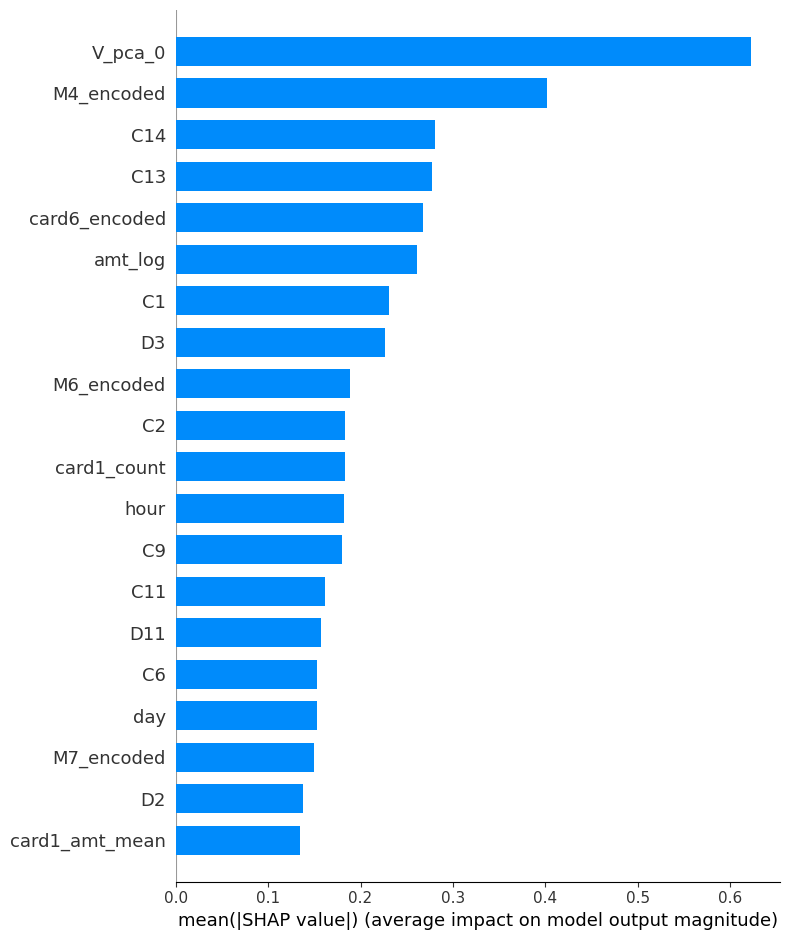

In [11]:
plt.figure()
shap.summary_plot(
    shap_values, X_shap,
    plot_type="bar",
    max_display=20,
    show=True
)

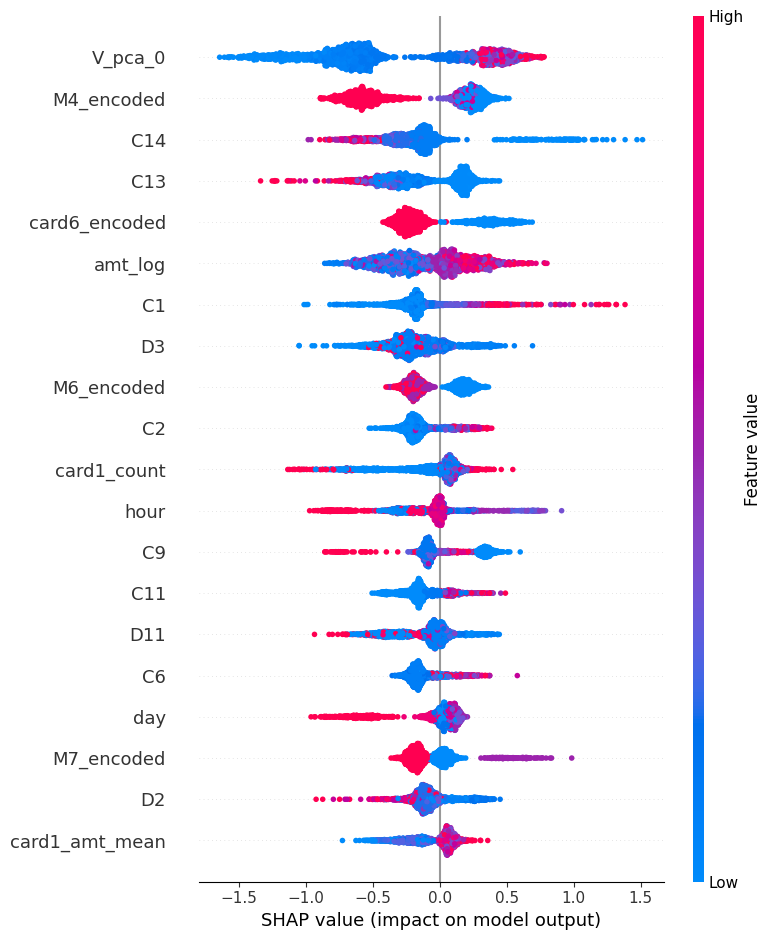

In [12]:
plt.figure()
shap.summary_plot(
    shap_values, X_shap,
    max_display=20,
    show=True
)


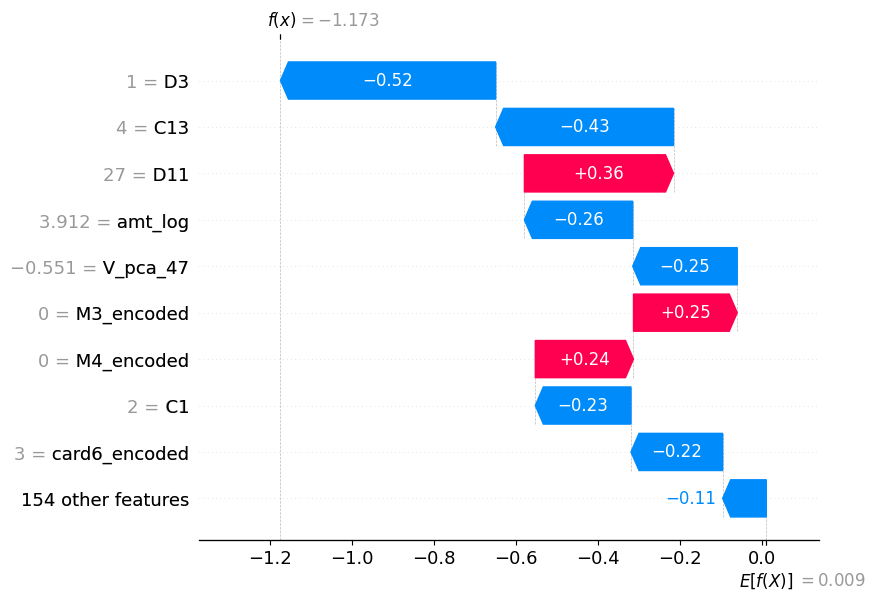

In [13]:
fraud_indices = np.where(y_shap == 1)[0]
first_fraud = fraud_indices[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[first_fraud],
        base_values=explainer.expected_value,
        data=X_shap.iloc[first_fraud],
        feature_names=X_shap.columns.tolist()
    )
)